# Figure 3A (UHVDB r6). Taxonomic annotation of UHVDB

Revision of `figure_3a.ipynb` using the released UHVDB r6 metadata table
(`toolkit2/databases/uhvdb/v6/analyze/uhvdb_metadata.tsv.gz`).

ICTV protein-similarity ranks and geNomad taxonomy are already joined into that
table (`ictv_*`, `genomad_taxonomy`), so the multi-file taxonomy joins from the
prior release are no longer needed.

Body-site stacked bars exclude `Other` (as before) and also exclude `Blood`.


In [27]:
### load packages
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

META = Path(
    "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB"
    "/toolkit2/databases/uhvdb/v6/analyze/uhvdb_metadata.tsv.gz"
)
OUTDIR = Path("plots")
OUTDIR.mkdir(exist_ok=True)


In [28]:
### Load UHVDB r6 metadata (unique genomovar representatives)
# Alias ICTV / taxonomy columns to match the original figure_3a analysis.
uhvdb_taxa_df = (
    pl.read_csv(
        META,
        separator="\t",
        columns=[
            "seq_name",
            "body_site",
            "seqhash_rep",
            "uhvdb_id",
            "genomovar_rep",
            "ictv_ref",
            "ictv_proteinsimilarity",
            "ictv_class",
            "ictv_order",
            "ictv_family",
            "ictv_genus",
            "ictv_species",
            "genomad_taxonomy",
        ],
        infer_schema_length=10000,
    )
    .filter(
        (pl.col("seq_name") == pl.col("seqhash_rep"))
        & (pl.col("uhvdb_id") == pl.col("genomovar_rep"))
    )
    .rename(
        {
            "ictv_proteinsimilarity": "normscore",
            "ictv_class": "Class",
            "ictv_order": "Order",
            "ictv_family": "Family",
            "ictv_genus": "Genus",
            "ictv_species": "Species",
            "ictv_ref": "ref",
            "genomad_taxonomy": "taxonomy",
        }
    )
    .with_columns(pl.col("normscore").fill_null(0.0))
)

print(f"total UHVDB genomovars: {uhvdb_taxa_df.height:,}")
print(uhvdb_taxa_df.group_by("body_site").len().sort("len", descending=True))


total UHVDB genomovars: 925,479
shape: (6, 2)
┌────────────┬────────┐
│ body_site  ┆ len    │
│ ---        ┆ ---    │
│ str        ┆ u32    │
╞════════════╪════════╡
│ Gut        ┆ 532722 │
│ Airways    ┆ 282136 │
│ Other      ┆ 85166  │
│ Blood      ┆ 9539   │
│ Skin       ┆ 8363   │
│ Urogenital ┆ 7553   │
└────────────┴────────┘


In [29]:
### Count number of queries with any hits to ICTV
print(
    "Number of UHVDB genomes with a hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col("normscore") > 0).height,
)


Number of UHVDB genomes with a hit to ICTV: 603363


In [30]:
### Count number of queries with family, subfamily, genus, subgenus, species level hits
print(
    "% of UHVDB genomes with family hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col("normscore") >= 5.5).height / uhvdb_taxa_df.height * 100,
)
print(
    "% of UHVDB genomes with subfamily hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col("normscore") >= 32).height / uhvdb_taxa_df.height * 100,
)
print(
    "% of UHVDB genomes with genus hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col("normscore") >= 65).height / uhvdb_taxa_df.height * 100,
)
print(
    "% of UHVDB genomes with subgenus hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col("normscore") >= 80).height / uhvdb_taxa_df.height * 100,
)
print(
    "% of UHVDB genomes with species hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col("normscore") >= 95).height / uhvdb_taxa_df.height * 100,
)


% of UHVDB genomes with family hit to ICTV: 65.19467216436028
% of UHVDB genomes with subfamily hit to ICTV: 18.46708569292226
% of UHVDB genomes with genus hit to ICTV: 11.587405008649574
% of UHVDB genomes with subgenus hit to ICTV: 8.562917148849406
% of UHVDB genomes with species hit to ICTV: 2.641983232466647


In [31]:
### Percent of genomovars with ICTV family / genus hits
# Thresholds from ICTV protein-similarity cutoffs used above (family ≥5.5%, genus ≥65%).
n_genomovars = uhvdb_taxa_df.height
n_family = uhvdb_taxa_df.filter(pl.col("normscore") >= 5.5).unique("genomovar_rep").height
n_genus = uhvdb_taxa_df.filter(pl.col("normscore") >= 65).unique("genomovar_rep").height

ictv_hit_summary = pl.DataFrame(
    {
        "rank": ["family", "genus"],
        "threshold": [5.5, 65.0],
        "n_genomovars_with_hit": [n_family, n_genus],
        "n_genomovars": [n_genomovars, n_genomovars],
        "percent": [
            n_family / n_genomovars * 100,
            n_genus / n_genomovars * 100,
        ],
    }
)
print(
    f"Family-level ICTV hits: {n_family:,} / {n_genomovars:,} "
    f"({n_family / n_genomovars * 100:.2f}%)"
)
print(
    f"Genus-level ICTV hits:  {n_genus:,} / {n_genomovars:,} "
    f"({n_genus / n_genomovars * 100:.2f}%)"
)
ictv_hit_summary


Family-level ICTV hits: 603,299 / 925,479 (65.19%)
Genus-level ICTV hits:  107,224 / 925,479 (11.59%)


rank,threshold,n_genomovars_with_hit,n_genomovars,percent
str,f64,i64,i64,f64
"""family""",5.5,603299,925479,65.187757
"""genus""",65.0,107224,925479,11.585784


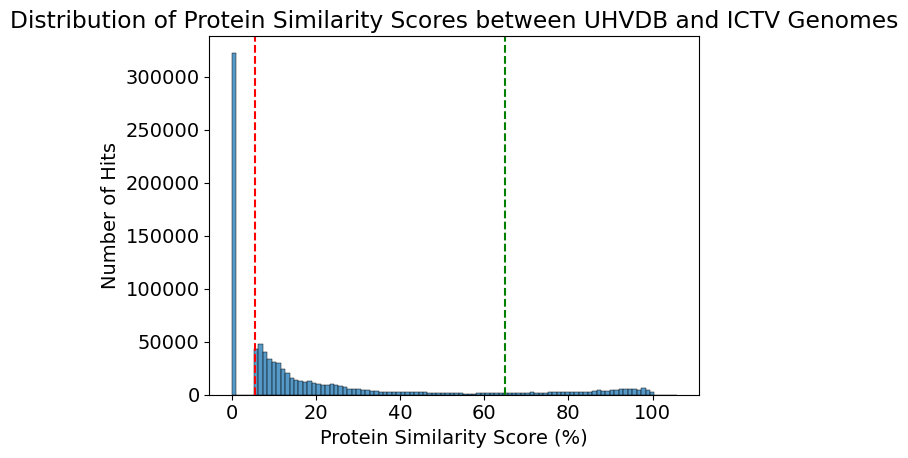

In [32]:
# create histogram of protein similarity scores
sns.histplot(
    data=uhvdb_taxa_df.group_by("uhvdb_id").agg(
        pl.col("normscore").max().alias("max_similarity")
    ),
    x="max_similarity",
    bins=100,
)
plt.xlabel("Protein Similarity Score (%)")
plt.ylabel("Number of Hits")
plt.title("Distribution of Protein Similarity Scores between UHVDB and ICTV Genomes")
plt.axvline(x=5.5, color="red", linestyle="--", label="Family Level Threshold (5.5%)")
plt.axvline(x=65, color="green", linestyle="--", label="Genus Level Threshold (65%)")
plt.tight_layout()
plt.savefig(OUTDIR / "figure_3a_ictv_similarity_hist_r6.png", dpi=300, bbox_inches="tight")
plt.show()


In [33]:
uhvdb_taxa_df.group_by("Class").len().sort("len", descending=True).head(15)


Class,len
str,u32
"""Caudoviricetes""",809203
"""Malgrandaviricetes""",49086
"""Faserviricetes""",14541
"""Revtraviricetes""",11205
"""Cardeaviricetes""",10870
…,…
"""Alsuviricetes""",1422
"""Arfiviricetes""",1169
"""Repensiviricetes""",1049


In [34]:
### Counts / percent of genomovars in selected ICTV classes
focal_classes = [
    "Caudoviricetes",
    "Malgrandaviricetes",
    "Faserviricetes",
    "Papovaviricetes",
    "Cardeaviricetes",
]
n_genomovars = uhvdb_taxa_df.height

class_counts = (
    uhvdb_taxa_df
    .filter(pl.col("Class").is_in(focal_classes))
    .group_by("Class")
    .len()
    .rename({"len": "n_genomovars"})
    .with_columns((pl.col("n_genomovars") / n_genomovars * 100).alias("percent"))
    .with_columns(pl.col("Class").cast(pl.Enum(focal_classes)))
    .sort("Class")
)

for row in class_counts.iter_rows(named=True):
    print(
        f"{row['Class']}: {row['n_genomovars']:,} / {n_genomovars:,} "
        f"({row['percent']:.2f}%)"
    )

n_focal = class_counts["n_genomovars"].sum()
print(
    f"\nCombined (these 5 classes): {n_focal:,} / {n_genomovars:,} "
    f"({n_focal / n_genomovars * 100:.2f}%)"
)
class_counts


Caudoviricetes: 809,203 / 925,479 (87.44%)
Malgrandaviricetes: 49,086 / 925,479 (5.30%)
Faserviricetes: 14,541 / 925,479 (1.57%)
Papovaviricetes: 3,090 / 925,479 (0.33%)
Cardeaviricetes: 10,870 / 925,479 (1.17%)

Combined (these 5 classes): 886,790 / 925,479 (95.82%)


Class,n_genomovars,percent
enum,u32,f64
"""Caudoviricetes""",809203,87.436128
"""Malgrandaviricetes""",49086,5.303848
"""Faserviricetes""",14541,1.571186
"""Papovaviricetes""",3090,0.333881
"""Cardeaviricetes""",10870,1.174527


In [35]:
uhvdb_taxa_df.filter(~pl.col("taxonomy").fill_null("").str.contains("Ribo")).group_by("Class").len().sort("len", descending=True).write_csv("class_counts_r6.tsv", separator="\t")
uhvdb_taxa_df.filter(~pl.col("taxonomy").fill_null("").str.contains("Ribo")).group_by("Class").len().sort("len", descending=True).head(15)


Class,len
str,u32
"""Caudoviricetes""",809203
"""Malgrandaviricetes""",49086
"""Faserviricetes""",14541
"""Cardeaviricetes""",10870
"""Papovaviricetes""",3090
…,…
"""Quintoviricetes""",504
"""Polintoviricetes""",387
"""Megaviricetes""",38


In [36]:
### Assign ICTV hits without a family-level hit to "Unclassified" category
uhvdb_taxa_df = uhvdb_taxa_df.with_columns(
    pl.when((pl.col("normscore") >= 5.5) & (pl.col("Family").is_not_null()))
    .then(pl.col("Family"))
    .when((pl.col("normscore") >= 5.5) & (pl.col("Family").is_null()))
    .then(pl.lit("Unclassified") + " " + pl.col("Class"))
    .alias("Family")
)


In [37]:
uhvdb_taxa_df.group_by("Family").len().sort("len", descending=True).head(10)


Family,len
str,u32
"""Unclassified Caudoviricetes""",360074
null,322116
"""Peduoviridae""",21452
"""Salasmaviridae""",18931
"""Aliceevansviridae""",11464
"""Anelloviridae""",10854
"""Litenviridae""",10299
"""Konodaiviridae""",9854
"""Suoliviridae""",9543


In [38]:
### Percent of ICTV hits (≥5.5%) that lack a named Family
# Among genomovars with normscore ≥ 5.5%, fraction assigned "Unclassified <Class>"
# (passes the family threshold, but no Family rank is available).
family_hits = uhvdb_taxa_df.filter(pl.col("normscore") >= 5.5)
n_family_hits = family_hits.height
n_no_named_family = family_hits.filter(
    pl.col("Family").is_null() | pl.col("Family").str.starts_with("Unclassified")
).height

print(
    f"ICTV hits (≥5.5%) without a named Family: "
    f"{n_no_named_family:,} / {n_family_hits:,} "
    f"({n_no_named_family / n_family_hits * 100:.2f}%)"
)
print(
    f"ICTV hits (≥5.5%) with a named Family: "
    f"{n_family_hits - n_no_named_family:,} / {n_family_hits:,} "
    f"({(n_family_hits - n_no_named_family) / n_family_hits * 100:.2f}%)"
)

pl.DataFrame(
    {
        "category": [
            "≥5.5% hit, no named Family",
            "≥5.5% hit, named Family",
        ],
        "n_genomovars": [n_no_named_family, n_family_hits - n_no_named_family],
        "percent_of_family_hits": [
            n_no_named_family / n_family_hits * 100,
            (n_family_hits - n_no_named_family) / n_family_hits * 100,
        ],
    }
)


ICTV hits (≥5.5%) without a named Family: 360,074 / 603,363 (59.68%)
ICTV hits (≥5.5%) with a named Family: 243,289 / 603,363 (40.32%)


category,n_genomovars,percent_of_family_hits
str,i64,f64
"""≥5.5% hit, no named Family""",360074,59.677839
"""≥5.5% hit, named Family""",243289,40.322161


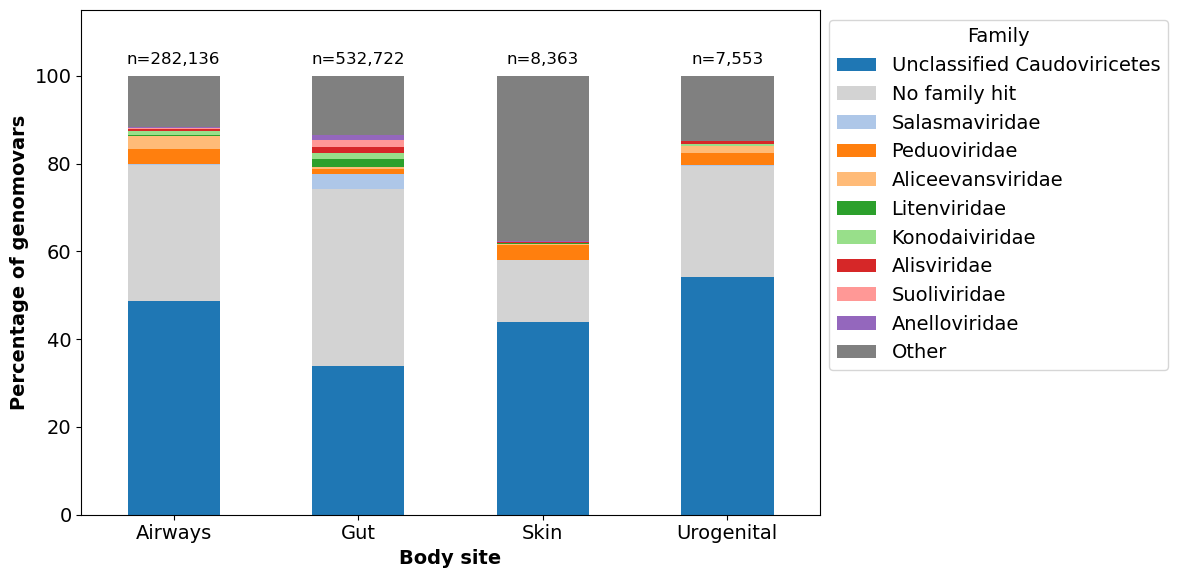

In [39]:
# Family composition by body site (exclude Other and Blood)
SITE_ORDER = ["Airways", "Gut", "Skin", "Urogenital"]

top_families = (
    uhvdb_taxa_df.group_by("Family").len().sort("len", descending=True).head(10)["Family"].to_list()
)

family_hits_classified = (
    uhvdb_taxa_df
    .filter(~pl.col("body_site").is_in(["Other", "Blood"]))
    .with_columns(
        pl.when(pl.col("Family").is_in(top_families))
        .then(pl.col("Family"))
        .when(pl.col("Family").is_null())
        .then(pl.lit("No family hit"))
        .otherwise(pl.lit("Other"))
        .alias("Family_classified")
    )
)

family_by_site = (
    family_hits_classified
    .group_by(["body_site", "Family_classified"])
    .len()
    .pivot(index="body_site", on="Family_classified", values="len", aggregate_function="sum")
    .fill_null(0)
)

family_by_site_pd = family_by_site.to_pandas().set_index("body_site")
family_by_site_pd = family_by_site_pd.reindex([s for s in SITE_ORDER if s in family_by_site_pd.index])

totals = family_by_site_pd.sum(axis=1)
family_proportions = family_by_site_pd.div(totals, axis=0) * 100

family_total_counts = family_by_site_pd.sum(axis=0)
if "Other" in family_total_counts.index:
    ordered_cols = (
        family_total_counts.drop("Other").sort_values(ascending=False).index.tolist() + ["Other"]
    )
else:
    ordered_cols = family_total_counts.sort_values(ascending=False).index.tolist()
family_proportions = family_proportions[ordered_cols]

plt.rcParams.update({"font.size": 14})
special_labels = {"No family hit", "Other"}
n_families = len([c for c in family_proportions.columns if c not in special_labels])
base_colors = plt.cm.tab20.colors[:n_families]
base_color_iter = iter(base_colors)
colors = []
for col in family_proportions.columns:
    if col == "No family hit":
        colors.append("#D3D3D3")
    elif col == "Other":
        colors.append("#808080")
    else:
        colors.append(next(base_color_iter))

ax = family_proportions.plot(kind="bar", stacked=True, figsize=(12, 6), color=colors)
plt.xticks(rotation=0)
plt.xlabel("Body site", fontdict={"fontweight": "bold"})
plt.ylabel("Percentage of genomovars", fontdict={"fontweight": "bold"})
plt.legend(title="Family", bbox_to_anchor=(1.0, 1), loc="upper left")

for i, (idx, total) in enumerate(totals.items()):
    ax.text(i, 102, f"n={int(total):,}", ha="center", va="bottom", fontsize=12)

plt.ylim(0, 115)
plt.tight_layout()
plt.savefig(OUTDIR / "figure_3a_family_by_body_site_r6.png", dpi=300, bbox_inches="tight")
family_proportions.to_csv(OUTDIR / "figure_3a_family_by_body_site_r6.tsv", sep="\t")
plt.show()


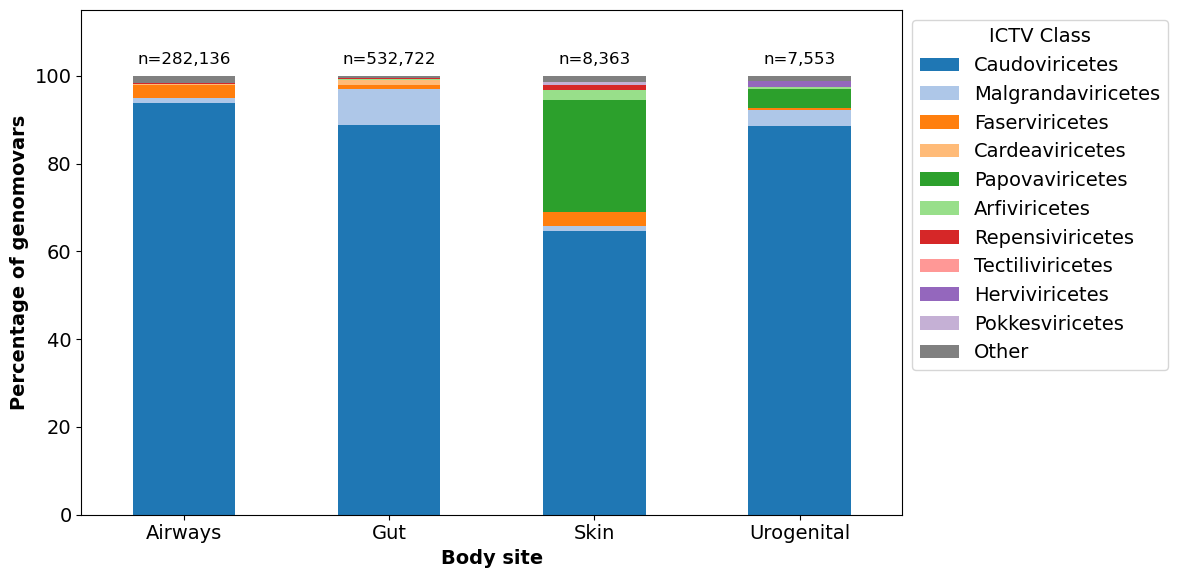

In [40]:
# ICTV Class composition by body site (exclude Riboviria/Ribozyviria, Other, Blood)
SITE_ORDER = ["Airways", "Gut", "Skin", "Urogenital"]

top_classes = (
    uhvdb_taxa_df
    .filter(~pl.col("taxonomy").fill_null("").str.contains("Ribo"))
    .group_by("Class")
    .len()
    .sort("len", descending=True)
    .head(10)["Class"].to_list()
)

class_hits_classified = (
    uhvdb_taxa_df
    .filter(~pl.col("body_site").is_in(["Other", "Blood"]))
    .with_columns(
        pl.when(pl.col("Class").is_in(top_classes))
        .then(pl.col("Class"))
        .when(pl.col("Class").is_null())
        .then(pl.lit("No class hit"))
        .otherwise(pl.lit("Other"))
        .alias("Class_classified")
    )
)

class_by_site = (
    class_hits_classified
    .group_by(["body_site", "Class_classified"])
    .len()
    .pivot(index="body_site", on="Class_classified", values="len", aggregate_function="sum")
    .fill_null(0)
)

class_by_site_pd = class_by_site.to_pandas().set_index("body_site")
class_by_site_pd = class_by_site_pd.reindex([s for s in SITE_ORDER if s in class_by_site_pd.index])

totals = class_by_site_pd.sum(axis=1)
class_proportions = class_by_site_pd.div(totals, axis=0) * 100

class_total_counts = class_by_site_pd.sum(axis=0)
if "Other" in class_total_counts.index:
    ordered_cols = (
        class_total_counts.drop("Other").sort_values(ascending=False).index.tolist() + ["Other"]
    )
else:
    ordered_cols = class_total_counts.sort_values(ascending=False).index.tolist()
class_proportions = class_proportions[ordered_cols]

plt.rcParams.update({"font.size": 14})
special_labels = {"No class hit", "Other"}
n_classes = len([c for c in class_proportions.columns if c not in special_labels])
base_colors = plt.cm.tab20.colors[:n_classes]
base_color_iter = iter(base_colors)
colors = []
for col in class_proportions.columns:
    if col == "No class hit":
        colors.append("#D3D3D3")
    elif col == "Other":
        colors.append("#808080")
    else:
        colors.append(next(base_color_iter))

ax = class_proportions.plot(kind="bar", stacked=True, figsize=(12, 6), color=colors)
plt.xticks(rotation=0)
plt.xlabel("Body site", fontdict={"fontweight": "bold"})
plt.ylabel("Percentage of genomovars", fontdict={"fontweight": "bold"})
plt.legend(title="ICTV Class", bbox_to_anchor=(1.0, 1), loc="upper left")

for i, (idx, total) in enumerate(totals.items()):
    ax.text(i, 102, f"n={int(total):,}", ha="center", va="bottom", fontsize=12)

plt.ylim(0, 115)
plt.tight_layout()
plt.savefig(OUTDIR / "figure_3a_class_by_body_site_r6.png", dpi=300, bbox_inches="tight")
class_proportions.to_csv(OUTDIR / "figure_3a_class_by_body_site_r6.tsv", sep="\t")
plt.show()


In [41]:
class_proportions

,Caudoviricetes,Malgrandaviricetes,Faserviricetes,Cardeaviricetes,Papovaviricetes,Arfiviricetes,Repensiviricetes,Tectiliviricetes,Herviviricetes,Pokkesviricetes,Other
body_site,,,,,,,,,,,
Airways,93.854737,1.021848,3.018048,0.259095,0.037216,0.058837,0.013823,0.063090,0.024102,0.025165,1.624039
Gut,88.910351,8.150593,0.776390,1.228220,0.021963,0.145104,0.170258,0.041485,0.000000,0.000188,0.555449
Skin,64.594045,1.100084,3.180677,0.143489,25.564989,2.259955,1.028339,0.000000,0.000000,0.717446,1.410977
Urogenital,88.627036,3.627698,0.357474,0.132398,4.369125,0.264795,0.039719,0.039719,1.456375,0.000000,1.085661
